In [22]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load Iris dataset
iris = load_iris()

# Features and target
X = iris.data
y = iris.target

# Display feature names
print("Features:", iris.feature_names)
print("Target names:", iris.target_names)

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA and reduce to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Print explained variance ratio
print("\nExplained Variance Ratio:")
print("Principal Component 1:", pca.explained_variance_ratio_[0])
print("Principal Component 2:", pca.explained_variance_ratio_[1])

# Total variance explained
print("\nTotal variance explained:",
      sum(pca.explained_variance_ratio_))

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']

Explained Variance Ratio:
Principal Component 1: 0.7296244541329991
Principal Component 2: 0.22850761786701745

Total variance explained: 0.9581320720000166


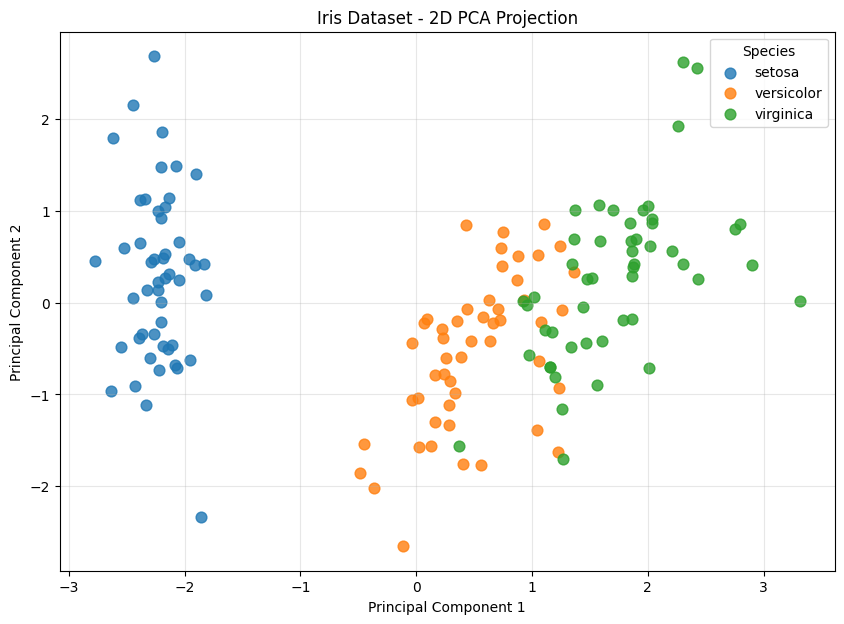

In [23]:
# Plot the PCA-transformed Iris dataset

plt.figure(figsize=(10, 7))

# Plot each species separately
for target_value, target_name in enumerate(iris.target_names):
    plt.scatter(
        X_pca[y == target_value, 0],
        X_pca[y == target_value, 1],
        label=target_name,
        s=60,
        alpha=0.8
    )

# Add labels and title
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Iris Dataset - 2D PCA Projection")

plt.legend(title="Species")
plt.grid(alpha=0.3)

plt.show()

In [24]:
import pandas as pd
import numpy as np

# Set random seed so results are reproducible
np.random.seed(42)

# Number of restaurants
n_restaurants = 200

# Create a sample Zomato-style dataset
zomato_data = pd.DataFrame({
    "average_cost_for_two": np.random.randint(100, 3000, n_restaurants),
    "price_range": np.random.randint(1, 5, n_restaurants),
    "aggregate_rating": np.round(np.random.uniform(2.0, 5.0, n_restaurants), 1),
    "votes": np.random.randint(10, 5000, n_restaurants),
    "table_booking": np.random.randint(0, 2, n_restaurants),
    "online_delivery": np.random.randint(0, 2, n_restaurants),
    "delivery_time": np.random.randint(15, 90, n_restaurants),
    "num_cuisines": np.random.randint(1, 10, n_restaurants),
    "restaurant_age": np.random.randint(1, 30, n_restaurants),
    "num_reviews": np.random.randint(5, 2000, n_restaurants)
})

# Save as CSV
zomato_data.to_csv("zomato_restaurant_ratings.csv", index=False)

print("CSV file created successfully!")
print(zomato_data.head())

CSV file created successfully!
   average_cost_for_two  price_range  aggregate_rating  votes  table_booking  \
0                   960            2               3.7   1334              0   
1                  1394            2               3.7   1165              1   
2                  1230            4               4.9   1837              1   
3                  1195            2               2.2   3151              0   
4                  1738            3               2.9   3496              0   

   online_delivery  delivery_time  num_cuisines  restaurant_age  num_reviews  
0                1             25             8              27          121  
1                0             37             1              27          390  
2                0             15             4              16         1372  
3                0             60             4               9          588  
4                0             35             3              13          399  


Dataset shape: (200, 10)

Columns:
['average_cost_for_two', 'price_range', 'aggregate_rating', 'votes', 'table_booking', 'online_delivery', 'delivery_time', 'num_cuisines', 'restaurant_age', 'num_reviews']

Number of features: 10

Explained Variance Ratio:
PC1: 0.1389
PC2: 0.1344
PC3: 0.1215

Cumulative Explained Variance:
First 1 component(s): 0.1389
First 2 component(s): 0.2733
First 3 component(s): 0.3948


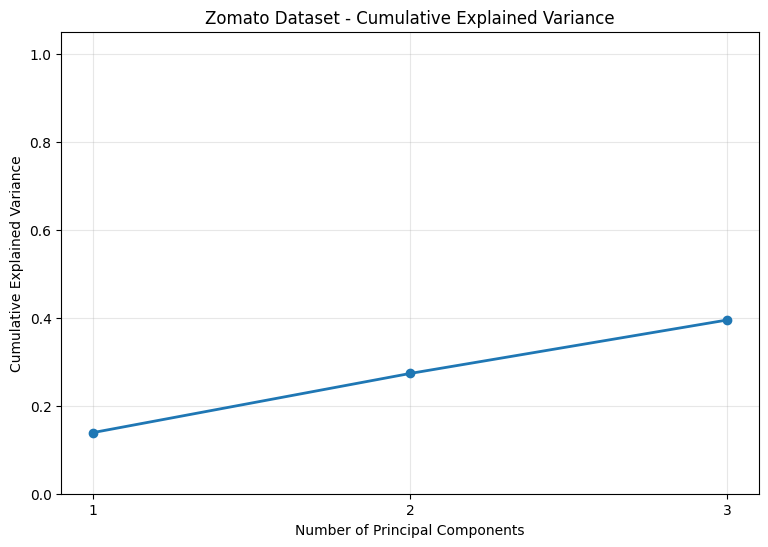

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load the Zomato CSV file
zomato = pd.read_csv("zomato_restaurant_ratings.csv")

# Display dataset information
print("Dataset shape:", zomato.shape)
print("\nColumns:")
print(zomato.columns.tolist())

# Select the 10 numerical features
X_zomato = zomato.select_dtypes(include=np.number)

print("\nNumber of features:", X_zomato.shape[1])

# Standardize the data
scaler = StandardScaler()
X_zomato_scaled = scaler.fit_transform(X_zomato)

# Apply PCA
pca_zomato = PCA(n_components=3)
X_zomato_pca = pca_zomato.fit_transform(X_zomato_scaled)

# Print explained variance
print("\nExplained Variance Ratio:")
for i, variance in enumerate(pca_zomato.explained_variance_ratio_, start=1):
    print(f"PC{i}: {variance:.4f}")

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(
    pca_zomato.explained_variance_ratio_
)

print("\nCumulative Explained Variance:")
for i, variance in enumerate(cumulative_variance, start=1):
    print(f"First {i} component(s): {variance:.4f}")

# Plot cumulative explained variance

components = np.arange(1, len(cumulative_variance) + 1)

plt.figure(figsize=(9, 6))

plt.plot(
    components,
    cumulative_variance,
    marker="o",
    linewidth=2
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Zomato Dataset - Cumulative Explained Variance")

plt.xticks(components)
plt.ylim(0, 1.05)

plt.grid(alpha=0.3)

plt.show()

Cluster Centroids:
[[ 0.57262144 -0.80720888]
 [-2.22475316  0.28892745]
 [ 1.72103664  0.60288719]]


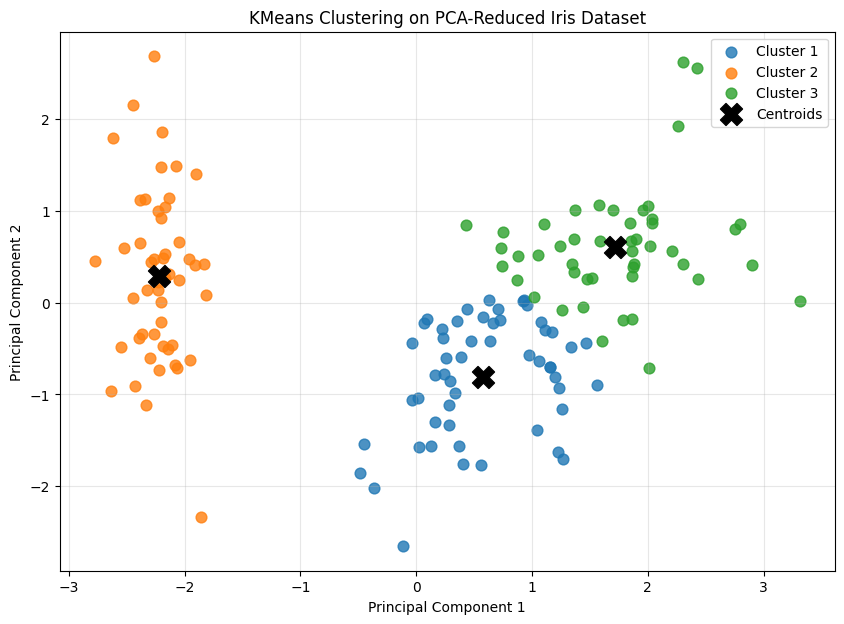

In [29]:
from sklearn.cluster import KMeans

# Create KMeans model with 3 clusters
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Fit KMeans and predict cluster labels
clusters = kmeans.fit_predict(X_pca)

# Get cluster centroids
centroids = kmeans.cluster_centers_

# Display centroids
print("Cluster Centroids:")
print(centroids)

plt.figure(figsize=(10, 7))

# Plot the clusters
for cluster_number in range(3):
    plt.scatter(
        X_pca[clusters == cluster_number, 0],
        X_pca[clusters == cluster_number, 1],
        s=60,
        alpha=0.8,
        label=f"Cluster {cluster_number + 1}"
    )

# Plot centroids
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="X",
    s=250,
    color="black",
    label="Centroids"
)

# Labels and title
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("KMeans Clustering on PCA-Reduced Iris Dataset")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [30]:
from sklearn.metrics import silhouette_score

# Calculate silhouette score
sil_score = silhouette_score(X_pca, clusters)

# Print the result
print("Silhouette Score:", sil_score)

Silhouette Score: 0.5091683341538228
